In [1]:
import zipfile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, LeakyReLU, LayerNormalization
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load dataset
def load_split_data(split_num):
    """Load data untuk split tertentu"""
    X_train = pd.read_csv(f'/content/drive/MyDrive/Penelitian Buk Iza/feature-engineering/X0-train-split{split_num}-seqglo-truncate.csv')
    X_test = pd.read_csv(f'/content/drive/MyDrive/Penelitian Buk Iza/feature-engineering/X0-test-split{split_num}-seqglo-truncate.csv')
    y_train = pd.read_csv(f'/content/drive/MyDrive/Penelitian Buk Iza/feature-engineering/y0-train-split{split_num}-seqglo-truncate.csv')
    y_test = pd.read_csv(f'/content/drive/MyDrive/Penelitian Buk Iza/feature-engineering/y0-test-split{split_num}-seqglo-truncate.csv')

    return X_train, X_test, y_train, y_test

# Load split pertama sebagai contoh
X_train, X_test, y_train, y_test = load_split_data(1)

print(f"Shape X_train: {X_train.shape}")
print(f"Shape X_test: {X_test.shape}")
print(f"Shape y_train: {y_train.shape}")
print(f"Shape y_test: {y_test.shape}")
print(f"\nFeatures: {list(X_train.columns)}")
print(f"Unique labels: {sorted(y_train['label'].unique())}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Penelitian Buk Iza/feature-engineering/X0-train-split1-seqglo-truncate.csv'

In [ ]:
np.unique(y_train, return_counts=True)

(array([1, 2]), array([102285, 102228]))

In [ ]:
# Fungsi untuk membuat sliding window
def create_sliding_window(data, window_size=60):
    """
    Membuat sliding window untuk data time series

    Args:
        data: numpy array atau pandas DataFrame
        window_size: ukuran window (default 60)

    Returns:
        X: array 3D dengan shape (samples, window_size, features)
        y: array 1D dengan label untuk setiap window
    """
    if isinstance(data, pd.DataFrame):
        features = data.drop('label', axis=1).values if 'label' in data.columns else data.values
        labels = data['label'].values if 'label' in data.columns else None
    else:
        features = data
        labels = None

    X, y = [], []

    for i in range(len(features) - window_size + 1):
        X.append(features[i:i + window_size])
        if labels is not None:
            # Ambil label terakhir dari window
            y.append(labels[i + window_size - 1])

    return np.array(X), np.array(y)

# Test fungsi sliding window
print("Testing sliding window function...")
sample_data = pd.concat([X_train.head(100), y_train.head(100)], axis=1)
X_sample, y_sample = create_sliding_window(sample_data, window_size=60)
print(f"Original data shape: {sample_data.shape}")
print(f"Windowed X shape: {X_sample.shape}")
print(f"Windowed y shape: {y_sample.shape}")

Testing sliding window function...
Original data shape: (100, 9)
Windowed X shape: (41, 60, 8)
Windowed y shape: (41,)


In [ ]:
# Data preprocessing dan normalisasi yang diperbaiki
def preprocess_data_improved(X_train, X_test, y_train, y_test, window_size=60):
    """
    Preprocessing data untuk LSTM dengan normalisasi yang benar
    """
    print("Melakukan preprocessing data...")

    # Copy data untuk menghindari modifikasi original
    X_train_copy = X_train.copy()
    X_test_copy = X_test.copy()
    y_train_copy = y_train.copy()
    y_test_copy = y_test.copy()

    # Cek dan handle missing values
    print(f"Missing values in X_train: {X_train_copy.isnull().sum().sum()}")
    print(f"Missing values in X_test: {X_test_copy.isnull().sum().sum()}")

    # Fill missing values dengan median
    if X_train_copy.isnull().sum().sum() > 0:
        X_train_copy = X_train_copy.fillna(X_train_copy.median())
    if X_test_copy.isnull().sum().sum() > 0:
        X_test_copy = X_test_copy.fillna(X_train_copy.median())  # Gunakan median dari train

    # Normalisasi fitur - HANYA fit pada training data
    scaler = StandardScaler()

    # Fit scaler HANYA pada data training
    X_train_scaled = scaler.fit_transform(X_train_copy)
    # Transform data testing menggunakan parameter dari training
    X_test_scaled = scaler.transform(X_test_copy)

    print(f"Training data - Mean: {X_train_scaled.mean():.6f}, Std: {X_train_scaled.std():.6f}")
    print(f"Testing data - Mean: {X_test_scaled.mean():.6f}, Std: {X_test_scaled.std():.6f}")

    # Convert back to DataFrame untuk memudahkan sliding window
    X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_copy.columns)
    X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test_copy.columns)

    # Gabungkan dengan labels
    train_data = pd.concat([X_train_scaled_df, y_train_copy.reset_index(drop=True)], axis=1)
    test_data = pd.concat([X_test_scaled_df, y_test_copy.reset_index(drop=True)], axis=1)

    # Buat sliding window
    print(f"Membuat sliding window dengan ukuran {window_size}...")
    X_train_window, y_train_window = create_sliding_window(train_data, window_size)
    X_test_window, y_test_window = create_sliding_window(test_data, window_size)

    # Encode labels
    label_encoder = LabelEncoder()
    y_train_encoded = label_encoder.fit_transform(y_train_window)
    y_test_encoded = label_encoder.transform(y_test_window)

    print(f"Window shapes - X_train: {X_train_window.shape}, X_test: {X_test_window.shape}")
    print(f"Label distribution - Train: {np.bincount(y_train_encoded)}, Test: {np.bincount(y_test_encoded)}")

    return X_train_window, X_test_window, y_train_encoded, y_test_encoded, scaler, label_encoder

# Preprocessing data dengan fungsi yang diperbaiki
print("=== Preprocessing data dengan normalisasi yang diperbaiki ===")
X_train_proc_new, X_test_proc_new, y_train_proc_new, y_test_proc_new, scaler_new, label_encoder_new = preprocess_data_improved(
    X_train, X_test, y_train, y_test, window_size=60
)

print(f"\nHasil preprocessing:")
print(f"X_train_processed shape: {X_train_proc_new.shape}")
print(f"X_test_processed shape: {X_test_proc_new.shape}")
print(f"y_train_processed shape: {y_train_proc_new.shape}")
print(f"y_test_processed shape: {y_test_proc_new.shape}")
print(f"Number of classes: {len(label_encoder_new.classes_)}")
print(f"Classes: {label_encoder_new.classes_}")

=== Preprocessing data dengan normalisasi yang diperbaiki ===
Melakukan preprocessing data...
Missing values in X_train: 0
Missing values in X_test: 0
Training data - Mean: -0.000000, Std: 1.000000
Testing data - Mean: -0.177704, Std: 1.135187
Membuat sliding window dengan ukuran 60...
Window shapes - X_train: (204454, 60, 8), X_test: (51101, 60, 8)
Label distribution - Train: [102285 102169], Test: [25575 25526]

Hasil preprocessing:
X_train_processed shape: (204454, 60, 8)
X_test_processed shape: (51101, 60, 8)
y_train_processed shape: (204454,)
y_test_processed shape: (51101,)
Number of classes: 2
Classes: [1 2]


In [ ]:
input_shape_new = (X_train_proc_new.shape[1], X_train_proc_new.shape[2])
num_classes_new = len(label_encoder_new.classes_)

In [ ]:
# Membuat model LSTM yang diperbaiki untuk mengatasi overfitting
def create_improved_lstm_model(input_shape, num_classes):
    """
    Membuat model LSTM dengan regularisasi yang lebih kuat untuk mengatasi overfitting
    """
    model = Sequential([
        # Layer LSTM dengan unit lebih kecil
        LSTM(256, return_sequences=True, input_shape=input_shape,
             kernel_regularizer=l2(0.001)),
        Dropout(0.3),  # Tambahkan dropout untuk mengurangi overfitting
        LayerNormalization(),

        LSTM(128, return_sequences=True,
             kernel_regularizer=l2(0.001)),
        Dropout(0.3),  # Tambahkan dropout untuk mengurangi overfitting
        LayerNormalization(),

        LSTM(64, return_sequences=False,
             kernel_regularizer=l2(0.001)),
        Dropout(0.5),
        LayerNormalization(),

        # Dense layer yang lebih efisien
        Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(0.5),
        LayerNormalization(),

        Dense(num_classes, activation='softmax')
    ])
    return model


# Buat model baru dengan arsitektur yang diperbaiki
input_shape_new = (X_train_proc_new.shape[1], X_train_proc_new.shape[2])
num_classes_new = len(label_encoder_new.classes_)

model_improved = create_improved_lstm_model(input_shape_new, num_classes_new)

# Compile model dengan learning rate yang lebih kecil
model_improved.compile(
    optimizer=RMSprop(learning_rate=0.0001),  # Learning rate lebih kecil
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Print model summary
print("Model Summary (Improved):")
model_improved.summary()
print(f"\nInput shape: {input_shape_new}")
print(f"Number of classes: {num_classes_new}")
print(f"Total parameters: {model_improved.count_params():,}")

Model Summary (Improved):


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 256)        │       271,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 60, 256)        │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 128)        │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 60, 128)        │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 64)             │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_3           │ (None, 128)            │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 527,618 (2.01 MB)

 Trainable params: 527,618 (2.01 MB)

 Non-trainable params: 0 (0.00 B)


Input shape: (60, 8)
Number of classes: 2
Total parameters: 527,618


In [ ]:
def train_improved_model_with_checkpoint(model, X_train, y_train, X_test, y_test, epochs=100, batch_size=64, checkpoint_path='best_model.h5'):
    """
    Training model LSTM dengan teknik anti-overfitting yang lebih agresif dan ModelCheckpoint
    """

    # Buat direktori untuk checkpoint jika belum ada
    checkpoint_dir = os.path.dirname(checkpoint_path)
    if checkpoint_dir and not os.path.exists(checkpoint_dir):
        os.makedirs(checkpoint_dir)

    # Callbacks yang lebih agresif
    early_stopping = EarlyStopping(
        monitor='val_accuracy',
        patience=15,  # Sedikit lebih panjang karena ada checkpoint
        restore_best_weights=True,
        verbose=1,
        min_delta=0.001,
        mode='max'
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.6,  # Lebih agresif dalam mengurangi LR
        patience=5,   # Lebih cepat mengurangi LR
        min_lr=1e-9,
        verbose=1,
        mode='max'
    )

    # ModelCheckpoint - simpan model terbaik
    model_checkpoint = ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,  # Hanya simpan model dengan val_accuracy terbaik
        save_weights_only=False,  # Simpan seluruh model (arsitektur + weights)
        mode='max',
        verbose=1,
        save_freq='epoch'  # Cek setiap epoch
    )

    # Training dengan batch size yang lebih besar untuk regularisasi
    print(f"Training dengan batch size: {batch_size}")
    print(f"Model checkpoint akan disimpan di: {checkpoint_path}")

    history  = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test, y_test),
        callbacks=[early_stopping, reduce_lr, model_checkpoint],
        verbose=1,
        # shuffle=True  # Shuffle data setiap epoch
    )

    return history, checkpoint_path

# Training model yang sudah diperbaiki
print("=== Memulai training model yang diperbaiki ===")
checkpoint_path = '/content/drive/MyDrive/Eye Tracker/model_checkpoints/best_lstm_model.h5'
history_improved, saved_checkpoint = train_improved_model_with_checkpoint(
    model_improved,
    X_train_proc_new, y_train_proc_new,
    X_test_proc_new, y_test_proc_new,
    epochs=100,
    batch_size=256,
    checkpoint_path=checkpoint_path
)

print(f"\nTraining selesai!")
print(f"Final training loss: {history_improved.history['loss'][-1]:.4f}")
print(f"Final validation loss: {history_improved.history['val_loss'][-1]:.4f}")
print(f"Final training accuracy: {history_improved.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {history_improved.history['val_accuracy'][-1]:.4f}")

=== Memulai training model yang diperbaiki ===
Training dengan batch size: 256
Model checkpoint akan disimpan di: /content/drive/MyDrive/Eye Tracker/model_checkpoints/best_lstm_model.h5
Epoch 1/100
799/799 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5246 - loss: 1.4279
Epoch 1: val_accuracy improved from -inf to 0.49347, saving model to /content/drive/MyDrive/Eye Tracker/model_checkpoints/best_lstm_model.h5


799/799 ━━━━━━━━━━━━━━━━━━━━ 39s 40ms/step - accuracy: 0.5246 - loss: 1.4278 - val_accuracy: 0.4935 - val_loss: 1.2662 - learning_rate: 1.0000e-04
Epoch 2/100
799/799 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5867 - loss: 1.0998
Epoch 2: val_accuracy improved from 0.49347 to 0.52244, saving model to /content/drive/MyDrive/Eye Tracker/model_checkpoints/best_lstm_model.h5


799/799 ━━━━━━━━━━━━━━━━━━━━ 38s 41ms/step - accuracy: 0.5867 - loss: 1.0997 - val_accuracy: 0.5224 - val_loss: 1.4121 - learning_rate: 1.0000e-04
Epoch 3/100
798/799 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6590 - loss: 0.9088
Epoch 3: val_accuracy improved from 0.52244 to 0.56537, saving model to /content/drive/MyDrive/Eye Tracker/model_checkpoints/best_lstm_model.h5


799/799 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.6590 - loss: 0.9087 - val_accuracy: 0.5654 - val_loss: 2.2025 - learning_rate: 1.0000e-04
Epoch 4/100
799/799 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7353 - loss: 0.7617
Epoch 4: val_accuracy improved from 0.56537 to 0.58157, saving model to /content/drive/MyDrive/Eye Tracker/model_checkpoints/best_lstm_model.h5


799/799 ━━━━━━━━━━━━━━━━━━━━ 43s 44ms/step - accuracy: 0.7353 - loss: 0.7617 - val_accuracy: 0.5816 - val_loss: 2.1319 - learning_rate: 1.0000e-04
Epoch 5/100
798/799 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7622 - loss: 0.6826
Epoch 5: val_accuracy improved from 0.58157 to 0.60860, saving model to /content/drive/MyDrive/Eye Tracker/model_checkpoints/best_lstm_model.h5


799/799 ━━━━━━━━━━━━━━━━━━━━ 41s 45ms/step - accuracy: 0.7622 - loss: 0.6826 - val_accuracy: 0.6086 - val_loss: 2.3611 - learning_rate: 1.0000e-04
Epoch 6/100
799/799 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7921 - loss: 0.6097
Epoch 6: val_accuracy did not improve from 0.60860
799/799 ━━━━━━━━━━━━━━━━━━━━ 37s 40ms/step - accuracy: 0.7921 - loss: 0.6096 - val_accuracy: 0.5858 - val_loss: 2.9175 - learning_rate: 1.0000e-04
Epoch 7/100
799/799 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8172 - loss: 0.5476
Epoch 7: val_accuracy improved from 0.60860 to 0.61071, saving model to /content/drive/MyDrive/Eye Tracker/model_checkpoints/best_lstm_model.h5


799/799 ━━━━━━━━━━━━━━━━━━━━ 44s 45ms/step - accuracy: 0.8172 - loss: 0.5476 - val_accuracy: 0.6107 - val_loss: 3.0527 - learning_rate: 1.0000e-04
Epoch 8/100
798/799 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8342 - loss: 0.4999
Epoch 8: val_accuracy improved from 0.61071 to 0.61492, saving model to /content/drive/MyDrive/Eye Tracker/model_checkpoints/best_lstm_model.h5


799/799 ━━━━━━━━━━━━━━━━━━━━ 41s 45ms/step - accuracy: 0.8342 - loss: 0.4999 - val_accuracy: 0.6149 - val_loss: 3.3291 - learning_rate: 1.0000e-04
Epoch 9/100
798/799 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8505 - loss: 0.4622
Epoch 9: val_accuracy improved from 0.61492 to 0.61830, saving model to /content/drive/MyDrive/Eye Tracker/model_checkpoints/best_lstm_model.h5


799/799 ━━━━━━━━━━━━━━━━━━━━ 36s 44ms/step - accuracy: 0.8505 - loss: 0.4622 - val_accuracy: 0.6183 - val_loss: 3.3197 - learning_rate: 1.0000e-04
Epoch 10/100
799/799 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8606 - loss: 0.4315
Epoch 10: val_accuracy improved from 0.61830 to 0.64459, saving model to /content/drive/MyDrive/Eye Tracker/model_checkpoints/best_lstm_model.h5


799/799 ━━━━━━━━━━━━━━━━━━━━ 41s 45ms/step - accuracy: 0.8606 - loss: 0.4315 - val_accuracy: 0.6446 - val_loss: 3.3101 - learning_rate: 1.0000e-04
Epoch 11/100
799/799 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8767 - loss: 0.3982
Epoch 11: val_accuracy did not improve from 0.64459
799/799 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.8767 - loss: 0.3982 - val_accuracy: 0.6164 - val_loss: 3.4471 - learning_rate: 1.0000e-04
Epoch 12/100
799/799 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8880 - loss: 0.3673
Epoch 12: val_accuracy did not improve from 0.64459
799/799 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - accuracy: 0.8880 - loss: 0.3673 - val_accuracy: 0.6237 - val_loss: 3.5815 - learning_rate: 1.0000e-04
Epoch 13/100
798/799 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9001 - loss: 0.3396
Epoch 13: val_accuracy did not improve from 0.64459
799/799 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.9001 - loss: 0.3396 - val_accuracy: 0.6229 - val_loss: 3.6631 - learning_rate: 

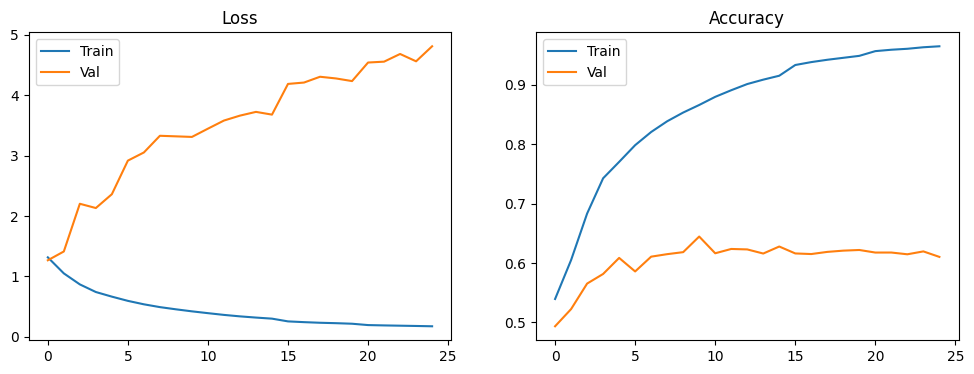

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title('Accuracy')
    plt.legend()

    plt.show()

plot_history(history_improved)

In [ ]:
# Membuat model LSTM yang diperbaiki untuk mengatasi overfitting
def create_improved_lstm_model2(input_shape, num_classes):
    """
    Membuat model LSTM dengan regularisasi yang lebih kuat untuk mengatasi overfitting
    """
    model = Sequential([
        # Layer LSTM dengan unit lebih kecil
        LSTM(256, return_sequences=True, input_shape=input_shape,
             kernel_regularizer=l2(0.001)),
        Dropout(0.3),  # Tambahkan dropout untuk mengurangi overfitting
        LayerNormalization(),

        LSTM(128, return_sequences=True,
             kernel_regularizer=l2(0.001)),
        Dropout(0.3),  # Tambahkan dropout untuk mengurangi overfitting
        LayerNormalization(),

        LSTM(64, return_sequences=False,
             kernel_regularizer=l2(0.001)),
        Dropout(0.5),
        LayerNormalization(),

        # Dense layer yang lebih efisien
        Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(0.5),
        LayerNormalization(),
        Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(0.5),
        LayerNormalization(),


        Dense(num_classes, activation='softmax')
    ])
    return model

model_improved2 = create_improved_lstm_model2(input_shape_new, num_classes_new)

# Compile model dengan learning rate yang lebih kecil
model_improved2.compile(
    optimizer=RMSprop(learning_rate=0.0001),  # Learning rate lebih kecil
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Print model summary
print("Model Summary (Improved):")
model_improved2.summary()
print(f"\nInput shape: {input_shape_new}")
print(f"Number of classes: {num_classes_new}")
print(f"Total parameters: {model_improved2.count_params():,}")

Model Summary (Improved):


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 60, 256)        │       271,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_4           │ (None, 60, 256)        │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 60, 128)        │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_5           │ (None, 60, 128)        │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_6           │ (None, 64)             │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_7           │ (None, 128)            │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_8           │ (None, 256)            │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 561,410 (2.14 MB)

 Trainable params: 561,410 (2.14 MB)

 Non-trainable params: 0 (0.00 B)


Input shape: (60, 8)
Number of classes: 2
Total parameters: 561,410


In [ ]:
def train_improved_model_with_checkpoint2(model, X_train, y_train, X_test, y_test, epochs=100, batch_size=64, checkpoint_path='best_model.h5'):
    """
    Training model LSTM dengan teknik anti-overfitting yang lebih agresif dan ModelCheckpoint
    """

    # Buat direktori untuk checkpoint jika belum ada
    checkpoint_dir = os.path.dirname(checkpoint_path)
    if checkpoint_dir and not os.path.exists(checkpoint_dir):
        os.makedirs(checkpoint_dir)

    # Callbacks yang lebih agresif
    early_stopping = EarlyStopping(
        monitor='val_accuracy',
        patience=15,  # Sedikit lebih panjang karena ada checkpoint
        restore_best_weights=True,
        verbose=1,
        min_delta=0.001,
        mode='max'
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.6,  # Lebih agresif dalam mengurangi LR
        patience=5,   # Lebih cepat mengurangi LR
        min_lr=1e-9,
        verbose=1,
        mode='max'
    )

    # ModelCheckpoint - simpan model terbaik
    model_checkpoint = ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,  # Hanya simpan model dengan val_accuracy terbaik
        save_weights_only=False,  # Simpan seluruh model (arsitektur + weights)
        mode='max',
        verbose=1,
        save_freq='epoch'  # Cek setiap epoch
    )

    # Training dengan batch size yang lebih besar untuk regularisasi
    print(f"Training dengan batch size: {batch_size}")
    print(f"Model checkpoint akan disimpan di: {checkpoint_path}")

    history  = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test, y_test),
        callbacks=[early_stopping, reduce_lr, model_checkpoint],
        verbose=1,
        # shuffle=True  # Shuffle data setiap epoch
    )

    return history, checkpoint_path

# Training model yang sudah diperbaiki
print("=== Memulai training model yang diperbaiki ===")
checkpoint_path2 = '/content/drive/MyDrive/Eye Tracker/model_checkpoints/best_lstm_model2.h5'
history_improved2, saved_checkpoint2 = train_improved_model_with_checkpoint2(
    model_improved2,
    X_train_proc_new, y_train_proc_new,
    X_test_proc_new, y_test_proc_new,
    epochs=100,
    batch_size=256,
    checkpoint_path=checkpoint_path2
)

print(f"\nTraining selesai!")
print(f"Final training loss: {history_improved2.history['loss'][-1]:.4f}")
print(f"Final validation loss: {history_improved2.history['val_loss'][-1]:.4f}")
print(f"Final training accuracy: {history_improved2.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {history_improved2.history['val_accuracy'][-1]:.4f}")

=== Memulai training model yang diperbaiki ===
Training dengan batch size: 256
Model checkpoint akan disimpan di: /content/drive/MyDrive/Eye Tracker/model_checkpoints/best_lstm_model2.h5
Epoch 1/100
798/799 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5149 - loss: 1.6107
Epoch 1: val_accuracy improved from -inf to 0.48962, saving model to /content/drive/MyDrive/Eye Tracker/model_checkpoints/best_lstm_model2.h5


799/799 ━━━━━━━━━━━━━━━━━━━━ 38s 42ms/step - accuracy: 0.5149 - loss: 1.6105 - val_accuracy: 0.4896 - val_loss: 1.8210 - learning_rate: 1.0000e-04
Epoch 2/100
798/799 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5730 - loss: 1.2485
Epoch 2: val_accuracy improved from 0.48962 to 0.52091, saving model to /content/drive/MyDrive/Eye Tracker/model_checkpoints/best_lstm_model2.h5


799/799 ━━━━━━━━━━━━━━━━━━━━ 36s 45ms/step - accuracy: 0.5730 - loss: 1.2483 - val_accuracy: 0.5209 - val_loss: 1.5830 - learning_rate: 1.0000e-04
Epoch 3/100
799/799 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6482 - loss: 1.0033
Epoch 3: val_accuracy improved from 0.52091 to 0.58394, saving model to /content/drive/MyDrive/Eye Tracker/model_checkpoints/best_lstm_model2.h5


799/799 ━━━━━━━━━━━━━━━━━━━━ 41s 45ms/step - accuracy: 0.6483 - loss: 1.0032 - val_accuracy: 0.5839 - val_loss: 2.0524 - learning_rate: 1.0000e-04
Epoch 4/100
798/799 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7190 - loss: 0.8413
Epoch 4: val_accuracy did not improve from 0.58394
799/799 ━━━━━━━━━━━━━━━━━━━━ 38s 41ms/step - accuracy: 0.7191 - loss: 0.8413 - val_accuracy: 0.5707 - val_loss: 2.3924 - learning_rate: 1.0000e-04
Epoch 5/100
799/799 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7600 - loss: 0.7314
Epoch 5: val_accuracy improved from 0.58394 to 0.60787, saving model to /content/drive/MyDrive/Eye Tracker/model_checkpoints/best_lstm_model2.h5


799/799 ━━━━━━━━━━━━━━━━━━━━ 34s 42ms/step - accuracy: 0.7600 - loss: 0.7313 - val_accuracy: 0.6079 - val_loss: 2.5110 - learning_rate: 1.0000e-04
Epoch 6/100
799/799 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7933 - loss: 0.6461
Epoch 6: val_accuracy did not improve from 0.60787
799/799 ━━━━━━━━━━━━━━━━━━━━ 40s 41ms/step - accuracy: 0.7934 - loss: 0.6460 - val_accuracy: 0.5951 - val_loss: 2.7102 - learning_rate: 1.0000e-04
Epoch 7/100
799/799 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8152 - loss: 0.5816
Epoch 7: val_accuracy did not improve from 0.60787
799/799 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - accuracy: 0.8152 - loss: 0.5816 - val_accuracy: 0.5900 - val_loss: 3.0348 - learning_rate: 1.0000e-04
Epoch 8/100
798/799 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8316 - loss: 0.5312
Epoch 8: val_accuracy did not improve from 0.60787
799/799 ━━━━━━━━━━━━━━━━━━━━ 44s 45ms/step - accuracy: 0.8316 - loss: 0.5312 - val_accuracy: 0.5908 - val_loss: 3.4353 - learning_rate: 1.0000

799/799 ━━━━━━━━━━━━━━━━━━━━ 42s 42ms/step - accuracy: 0.8876 - loss: 0.3840 - val_accuracy: 0.6138 - val_loss: 3.6724 - learning_rate: 6.0000e-05
Epoch 12/100
798/799 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8936 - loss: 0.3653
Epoch 12: val_accuracy improved from 0.61376 to 0.61598, saving model to /content/drive/MyDrive/Eye Tracker/model_checkpoints/best_lstm_model2.h5


799/799 ━━━━━━━━━━━━━━━━━━━━ 44s 46ms/step - accuracy: 0.8936 - loss: 0.3652 - val_accuracy: 0.6160 - val_loss: 3.6195 - learning_rate: 6.0000e-05
Epoch 13/100
798/799 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9010 - loss: 0.3481
Epoch 13: val_accuracy improved from 0.61598 to 0.61758, saving model to /content/drive/MyDrive/Eye Tracker/model_checkpoints/best_lstm_model2.h5


799/799 ━━━━━━━━━━━━━━━━━━━━ 41s 45ms/step - accuracy: 0.9010 - loss: 0.3480 - val_accuracy: 0.6176 - val_loss: 3.6129 - learning_rate: 6.0000e-05
Epoch 14/100
799/799 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9068 - loss: 0.3288
Epoch 14: val_accuracy did not improve from 0.61758
799/799 ━━━━━━━━━━━━━━━━━━━━ 40s 44ms/step - accuracy: 0.9068 - loss: 0.3288 - val_accuracy: 0.5975 - val_loss: 3.9177 - learning_rate: 6.0000e-05
Epoch 15/100
798/799 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9115 - loss: 0.3161
Epoch 15: val_accuracy did not improve from 0.61758
799/799 ━━━━━━━━━━━━━━━━━━━━ 38s 41ms/step - accuracy: 0.9115 - loss: 0.3161 - val_accuracy: 0.6084 - val_loss: 3.8034 - learning_rate: 6.0000e-05
Epoch 16/100
799/799 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9176 - loss: 0.3035
Epoch 16: val_accuracy did not improve from 0.61758
799/799 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.9176 - loss: 0.3035 - val_accuracy: 0.6040 - val_loss: 3.8194 - learning_rate: 

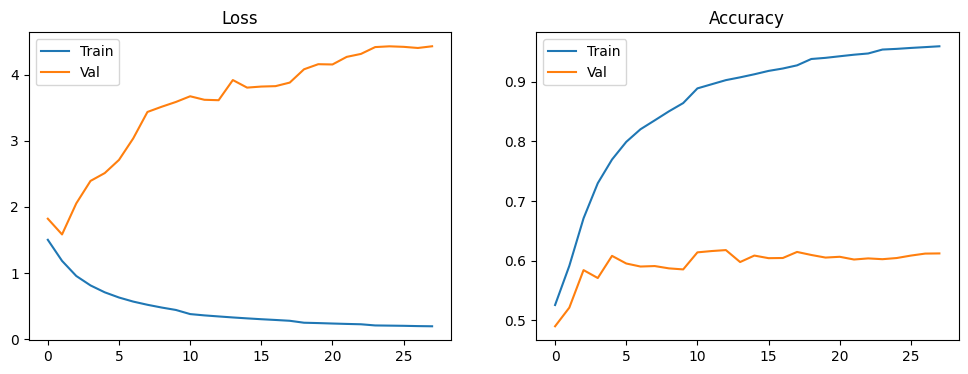

In [ ]:
import matplotlib.pyplot as plt

def plot_history2(history):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title('Accuracy')
    plt.legend()

    plt.show()

plot_history2(history_improved2)

In [ ]:
# Membuat model LSTM yang diperbaiki untuk mengatasi overfitting
def create_improved_lstm_model3(input_shape, num_classes):
    """
    Membuat model LSTM dengan regularisasi yang lebih kuat untuk mengatasi overfitting
    """
    model = Sequential([
        # Layer LSTM dengan unit lebih kecil
        LSTM(256, return_sequences=True, input_shape=input_shape,
             kernel_regularizer=l2(0.0001)),
        Dropout(0.3),  # Tambahkan dropout untuk mengurangi overfitting
        LayerNormalization(),

        LSTM(128, return_sequences=True,
             kernel_regularizer=l2(0.0001)),
        Dropout(0.3),  # Tambahkan dropout untuk mengurangi overfitting
        LayerNormalization(),

        LSTM(64, return_sequences=False,
             kernel_regularizer=l2(0.0001)),
        Dropout(0.5),
        LayerNormalization(),

        # Dense layer yang lebih efisien
        Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(0.8),
        LayerNormalization(),
        Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(0.8),
        LayerNormalization(),


        Dense(num_classes, activation='softmax')
    ])
    return model

model_improved3 = create_improved_lstm_model2(input_shape_new, num_classes_new)

# Compile model dengan learning rate yang lebih kecil
model_improved3.compile(
    optimizer=RMSprop(learning_rate=0.0001),  # Learning rate lebih kecil
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Print model summary
print("Model Summary (Improved):")
model_improved3.summary()
print(f"\nInput shape: {input_shape_new}")
print(f"Number of classes: {num_classes_new}")
print(f"Total parameters: {model_improved3.count_params():,}")

Model Summary (Improved):


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 60, 256)        │       271,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 60, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_14          │ (None, 60, 256)        │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 60, 128)        │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_15          │ (None, 60, 128)        │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_16          │ (None, 64)             │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_17          │ (None, 128)            │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_18          │ (None, 256)            │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 561,410 (2.14 MB)

 Trainable params: 561,410 (2.14 MB)

 Non-trainable params: 0 (0.00 B)


Input shape: (60, 8)
Number of classes: 2
Total parameters: 561,410


In [ ]:
def train_improved_model_with_checkpoint3(model, X_train, y_train, X_test, y_test, epochs=100, batch_size=64, checkpoint_path='best_model.h5'):
    """
    Training model LSTM dengan teknik anti-overfitting yang lebih agresif dan ModelCheckpoint
    """

    # Buat direktori untuk checkpoint jika belum ada
    checkpoint_dir = os.path.dirname(checkpoint_path)
    if checkpoint_dir and not os.path.exists(checkpoint_dir):
        os.makedirs(checkpoint_dir)

    # Callbacks yang lebih agresif
    early_stopping = EarlyStopping(
        monitor='val_accuracy',
        patience=15,  # Sedikit lebih panjang karena ada checkpoint
        restore_best_weights=True,
        verbose=1,
        min_delta=0.001,
        mode='max'
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.6,  # Lebih agresif dalam mengurangi LR
        patience=5,   # Lebih cepat mengurangi LR
        min_lr=1e-9,
        verbose=1,
        mode='max'
    )

    # ModelCheckpoint - simpan model terbaik
    model_checkpoint = ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,  # Hanya simpan model dengan val_accuracy terbaik
        save_weights_only=False,  # Simpan seluruh model (arsitektur + weights)
        mode='max',
        verbose=1,
        save_freq='epoch'  # Cek setiap epoch
    )

    # Training dengan batch size yang lebih besar untuk regularisasi
    print(f"Training dengan batch size: {batch_size}")
    print(f"Model checkpoint akan disimpan di: {checkpoint_path}")

    history  = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test, y_test),
        callbacks=[early_stopping, reduce_lr, model_checkpoint],
        verbose=1,
        shuffle=True  # Shuffle data setiap epoch
    )

    return history, checkpoint_path

# Training model yang sudah diperbaiki
print("=== Memulai training model yang diperbaiki ===")
checkpoint_path3 = '/content/drive/MyDrive/Eye Tracker/model_checkpoints/best_lstm_model3.h5'
history_improved3, saved_checkpoint3 = train_improved_model_with_checkpoint3(
    model_improved3,
    X_train_proc_new, y_train_proc_new,
    X_test_proc_new, y_test_proc_new,
    epochs=100,
    batch_size=128,
    checkpoint_path=checkpoint_path3
)

print(f"\nTraining selesai!")
print(f"Final training loss: {history_improved3.history['loss'][-1]:.4f}")
print(f"Final validation loss: {history_improved3.history['val_loss'][-1]:.4f}")
print(f"Final training accuracy: {history_improved3.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {history_improved3.history['val_accuracy'][-1]:.4f}")

=== Memulai training model yang diperbaiki ===
Training dengan batch size: 128
Model checkpoint akan disimpan di: /content/drive/MyDrive/Eye Tracker/model_checkpoints/best_lstm_model3.h5
Epoch 1/100
1598/1598 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5155 - loss: 1.6295
Epoch 1: val_accuracy improved from -inf to 0.49549, saving model to /content/drive/MyDrive/Eye Tracker/model_checkpoints/best_lstm_model3.h5


1598/1598 ━━━━━━━━━━━━━━━━━━━━ 49s 28ms/step - accuracy: 0.5155 - loss: 1.6294 - val_accuracy: 0.4955 - val_loss: 1.7143 - learning_rate: 1.0000e-04
Epoch 2/100
1597/1598 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5838 - loss: 1.1416
Epoch 2: val_accuracy improved from 0.49549 to 0.54793, saving model to /content/drive/MyDrive/Eye Tracker/model_checkpoints/best_lstm_model3.h5


1598/1598 ━━━━━━━━━━━━━━━━━━━━ 45s 28ms/step - accuracy: 0.5838 - loss: 1.1415 - val_accuracy: 0.5479 - val_loss: 2.1989 - learning_rate: 1.0000e-04
Epoch 3/100
1596/1598 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6743 - loss: 0.8711
Epoch 3: val_accuracy improved from 0.54793 to 0.60717, saving model to /content/drive/MyDrive/Eye Tracker/model_checkpoints/best_lstm_model3.h5


1598/1598 ━━━━━━━━━━━━━━━━━━━━ 45s 28ms/step - accuracy: 0.6744 - loss: 0.8710 - val_accuracy: 0.6072 - val_loss: 2.0095 - learning_rate: 1.0000e-04
Epoch 4/100
1597/1598 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7494 - loss: 0.7068
Epoch 4: val_accuracy did not improve from 0.60717
1598/1598 ━━━━━━━━━━━━━━━━━━━━ 81s 27ms/step - accuracy: 0.7494 - loss: 0.7068 - val_accuracy: 0.5944 - val_loss: 2.4663 - learning_rate: 1.0000e-04
Epoch 5/100
1598/1598 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7907 - loss: 0.5989
Epoch 5: val_accuracy did not improve from 0.60717
1598/1598 ━━━━━━━━━━━━━━━━━━━━ 83s 28ms/step - accuracy: 0.7907 - loss: 0.5989 - val_accuracy: 0.5965 - val_loss: 2.7942 - learning_rate: 1.0000e-04
Epoch 6/100
1598/1598 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8225 - loss: 0.5168
Epoch 6: val_accuracy improved from 0.60717 to 0.61625, saving model to /content/drive/MyDrive/Eye Tracker/model_checkpoints/best_lstm_model3.h5


1598/1598 ━━━━━━━━━━━━━━━━━━━━ 81s 28ms/step - accuracy: 0.8225 - loss: 0.5168 - val_accuracy: 0.6163 - val_loss: 2.6215 - learning_rate: 1.0000e-04
Epoch 7/100
1596/1598 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8426 - loss: 0.4607
Epoch 7: val_accuracy did not improve from 0.61625
1598/1598 ━━━━━━━━━━━━━━━━━━━━ 81s 27ms/step - accuracy: 0.8426 - loss: 0.4607 - val_accuracy: 0.5905 - val_loss: 3.0844 - learning_rate: 1.0000e-04
Epoch 8/100
1598/1598 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8594 - loss: 0.4169
Epoch 8: val_accuracy did not improve from 0.61625
1598/1598 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.8594 - loss: 0.4168 - val_accuracy: 0.5837 - val_loss: 3.3307 - learning_rate: 1.0000e-04
Epoch 9/100
1598/1598 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8770 - loss: 0.3783
Epoch 9: val_accuracy did not improve from 0.61625
1598/1598 ━━━━━━━━━━━━━━━━━━━━ 85s 29ms/step - accuracy: 0.8770 - loss: 0.3783 - val_accuracy: 0.5798 - val_loss: 3.4004 - learnin